In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

import encosid

In [2]:
MOTOR_IF = "can0"
MOTOR_ID = 3
BRAKE_ID = 4

SIGNAL_DT_MS = 1
MOTOR_KT = 4.2

size: 10
here
there


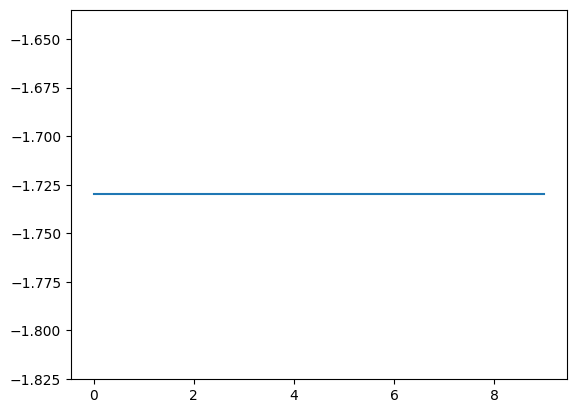

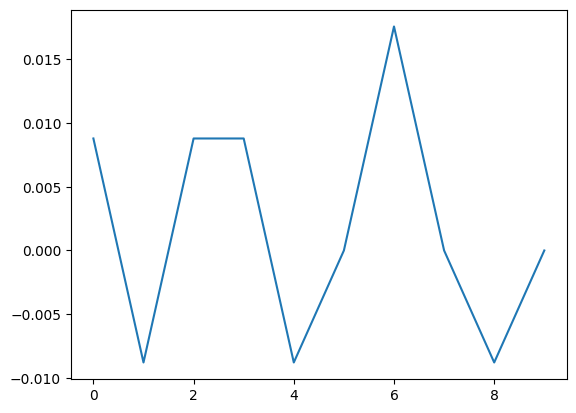

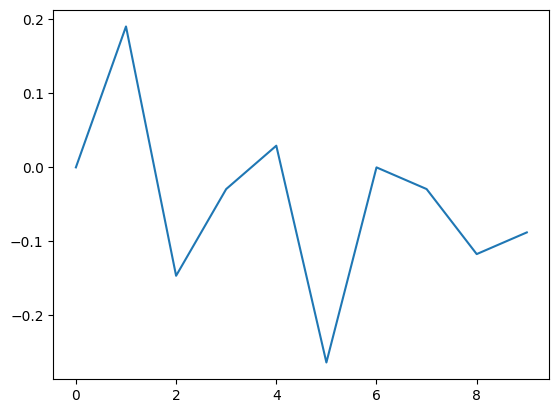

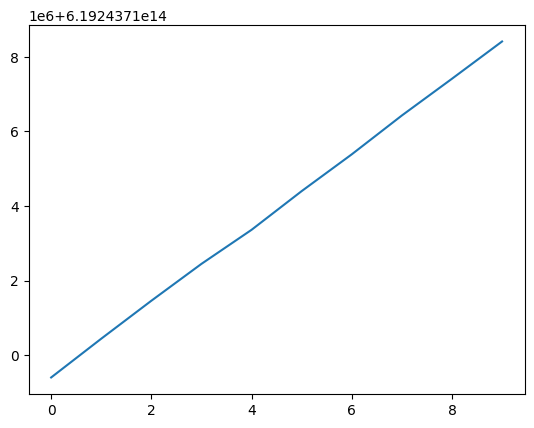

{0}


In [3]:
gen = encosid.SignalGenerator(MOTOR_IF)

data = np.zeros(1000)

motor_in = encosid.SignalGenerator.MotorInput(
  id=MOTOR_ID,
  scales=encosid.scales.a8112_as_docs,
  pos=np.zeros(10),
  vel=np.zeros(10),
  trq=np.zeros(10),
  kp=np.zeros(10),
  kd=np.zeros(10)
)
gen.play_signal((motor_in,), SIGNAL_DT_MS)

motor_out, = gen.gather()
plt.plot(motor_out.pos); plt.show()
plt.plot(motor_out.vel); plt.show()
plt.plot(motor_out.cur); plt.show()
plt.plot(motor_out.ts); plt.show()
print(set(motor_out.status))


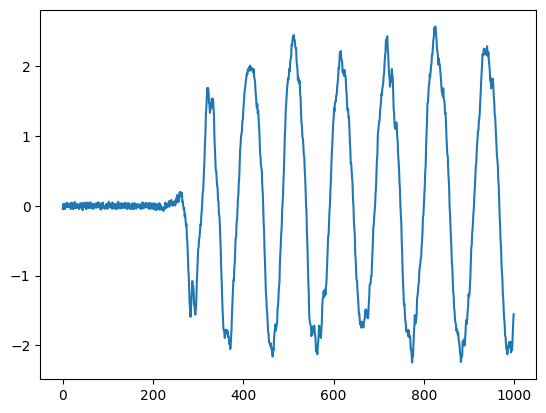

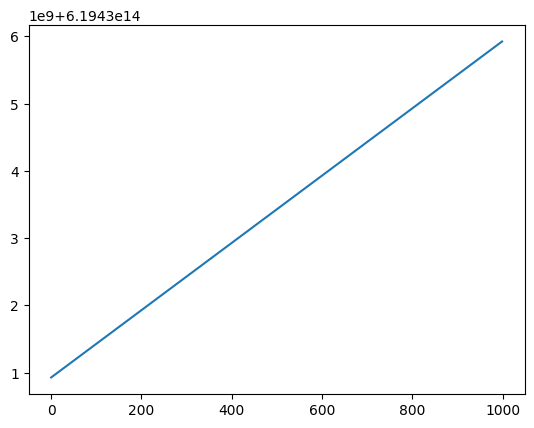

In [3]:
import numpy as np

rec = encosid.Recorder(port="/dev/ttyUSB0", tare=True)
rec.record(seconds=5.0, period_ms=5.0)   # возвращает управление сразу

time.sleep(5.0)                          # ждём окончания записи

out = rec.gather()                       # дожидается конца записи
out.values      # np.float32, момент
out.timestamps  # np.uint64, наносекунды CLOCK_MONOTONIC
out.statuses    # np.uint8, код на отсчёт (0 = ok)

plt.plot(out.values); plt.show()
plt.plot(out.timestamps); plt.show()